kpt_shape: [4, 3]
4 keypoints

3 values per keypoint : [x, y, visibility]


Corner 1:
x = 0.15
y = 0.20
visibility = 2

Corner 2:
x = 0.85
y = 0.18
visibility = 2

Corner 3:
x = 0.10
y = 0.85
visibility = 2

Corner 4:
x = 0.90
y = 0.83
visibility = 2

┌───────┬───────────────────────────────┬──────────────────────────────────────┐
│ Class │ Bounding Box                  │ Keypoints                            │
├───────┼───────────────────────────────┼──────────────────────────────────────┤
│   0   │ x y width height              │ (x,y,v) (x,y,v) (x,y,v) (x,y,v)      
└───────┴───────────────────────────────┴──────────────────────────────────────┘

In [150]:
import cv2
import matplotlib.pyplot as plt

def visualize_yolo_pose(image_path, label_path):
    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    # Read YOLO pose label
    with open(label_path, "r") as f:
        lines = f.readlines()

    # Color palette (RGB)
    colors = [
        (255, 0, 0),    # KP1: Red (Bottom-Left)
        (0, 255, 0),    # KP2: Green (Bottom-Right)
        (0, 0, 255),    # KP3: Blue (Top-Right)
        (255, 255, 0)   # KP4: Yellow (Top-Left)
    ]
    corner_names = ["BL", "BR", "TR", "TL"]

    for line in lines:
        values = list(map(float, line.strip().split()))
        if len(values) < 5:
            continue

        # 1. Bounding Box (cx, cy, bw, bh)
        cx, cy, bw, bh = values[1:5]
        xmin = int((cx - bw / 2) * w)
        ymin = int((cy - bh / 2) * h)
        xmax = int((cx + bw / 2) * w)
        ymax = int((cy + bh / 2) * h)

        # # Draw Court Bounding Box
        # cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (0, 255, 255), 2)
        # cv2.putText(image, "Court BBox", (xmin, max(ymin - 10, 20)),
        #             cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

        # 2. Keypoints (4 corners: x, y, visibility)
        raw_kpts = values[5:]
        kpts = []
        for i in range(0, len(raw_kpts), 3):
            kx = int(raw_kpts[i] * w)
            ky = int(raw_kpts[i + 1] * h)
            vis = int(raw_kpts[i + 2])
            kpts.append((kx, ky, vis))

        # Draw connecting polygon between the 4 court corners
        if len(kpts) == 4:
            pts_poly = [(kpts[i][0], kpts[i][1]) for i in range(4)]
            # Draw lines: BL -> BR -> TR -> TL -> BL
            for i in range(4):
                p1 = pts_poly[i]
                p2 = pts_poly[(i + 1) % 4]
                cv2.line(image, p1, p2, (255, 255, 255), 2)

        # Draw individual keypoints
        for idx, (kx, ky, vis) in enumerate(kpts):
            if vis > 0:  # If visible/labeled
                color = colors[idx % len(colors)]
                cv2.circle(image, (kx, ky), radius=8, color=color, thickness=-1)
                cv2.putText(image, f"{corner_names[idx]} (KP{idx+1})", (kx + 10, ky - 5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2)

    # Display visualized image
    plt.figure(figsize=(12, 7))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Tennis Court Detection - BBox & 4-Corner Pose", fontsize=14)
    plt.show()



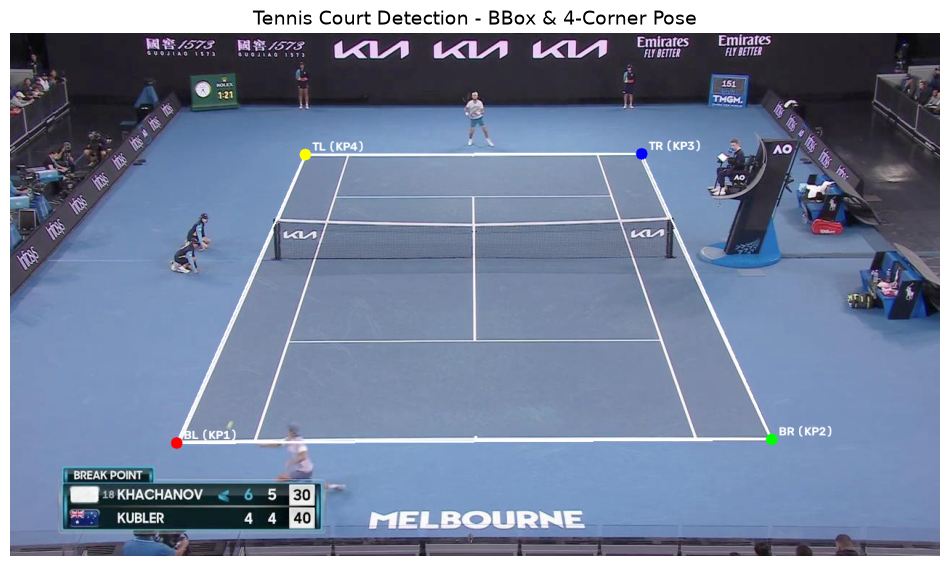

In [151]:
visualize_yolo_pose(image_path="../Tennis-Court-detection-yolov8/train/images/frame_100_jpg.rf.0127b042f5b9049798709270a66e80bb.jpg", label_path="../Tennis-Court-detection-yolov8/train/labels/frame_100_jpg.rf.0127b042f5b9049798709270a66e80bb.txt")

In [152]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import os
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

                    Dataset
                       │
             ┌─────────┴─────────┐
             │                   │
          image.jpg           image.txt
             │                   │
             ▼                   ▼
        PIL Image          Parse label
             │                   │
             │             4 keypoints
             │                   │
             │              [4, 2] tensor
             │                   │
             └─────────┬─────────┘
                       ▼
                __getitem__()
                       │
                       ▼
                image, label

TennisCourtDataset
│
├── __init__
│   │
│   ├── Find images
│   │
│   ├── Find corresponding labels
│   │
│   ├── Read label
│   │
│   ├── Remove class + bbox
│   │
│   ├── Remove visibility
│   │
│   └── Store [4, 2] keypoints
│
├── __len__
│   └── Number of valid images
│
└── __getitem__
    │
    ├── Load image
    ├── Apply transform
    └── Return image + keypoints

In [153]:
court_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

In [170]:
class TennisCourtDataset(Dataset):
    def __init__(self, data_dir, transforms=None):
        self.data_dir = data_dir
        self.images_dir = os.path.join(self.data_dir, "images")
        self.labels_dir = os.path.join(self.data_dir, "labels")
        self.transforms = transforms
        self.images = []
        self.labels = []

        exclueded = [n for n in range(138,144)]
        for i, img_name in enumerate(sorted(os.listdir(self.images_dir))):
            if i in exclueded:
                continue
            if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            img_path = os.path.join(self.images_dir, img_name)

            label_name = os.path.splitext(img_name)[0] + ".txt"
            label_path = os.path.join(self.labels_dir, label_name)

            # Skip if label doesn't exist
            if not os.path.exists(label_path):
                continue

            with open(label_path, 'r') as f:
                line = f.readline()


            lines = line.strip().split()
            values = list(map(float, lines[5:]))
            key_points_lst = []
            not_included = [2, 5, 8, 11]
            for i, val in enumerate(values):
                if i in not_included:
                    continue
                key_points_lst.append(val)
            matrix = [key_points_lst[i:i+2] for i in range(0, len(key_points_lst), 2)]

            self.images.append(img_path)
            self.labels.append(torch.tensor(matrix, dtype=torch.float32))


    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_path = self.images[index]
        label = self.labels[index]

        img = Image.open(img_path).convert("RGB")

        if self.transforms:
            img = self.transforms(img)
        
        return img, label



In [171]:
obj = TennisCourtDataset(data_dir="/home/etman/etman/tennis_analysis/Tennis-Court-detection-yolov8/train",
                         transforms=court_transforms)

In [169]:
# for i in range(len(obj)):
#     image, target = obj[i]

#     if target.numel() == 0:
#         print("Empty target at index:", i)
#     else:
#         print(i, target.shape)

# for i in range(138, 144):
#     print(i)
#     print("image:", obj.images[i])
#     print("label:", obj.labels[i])

138
image: /home/etman/etman/tennis_analysis/Tennis-Court-detection-yolov8/train/images/frame_166_jpg.rf.61cedd157293e7cb4130f849c9302648.jpg
label: tensor([])
139
image: /home/etman/etman/tennis_analysis/Tennis-Court-detection-yolov8/train/images/frame_166_jpg.rf.88d5b34ca1c2b7997faec9d550c72b9c.jpg
label: tensor([])
140
image: /home/etman/etman/tennis_analysis/Tennis-Court-detection-yolov8/train/images/frame_166_jpg.rf.b0237907bddf2f9b26e13cf7aff55e51.jpg
label: tensor([])
141
image: /home/etman/etman/tennis_analysis/Tennis-Court-detection-yolov8/train/images/frame_167_jpg.rf.6b9d881e338fa358e3d8f74fe930cea4.jpg
label: tensor([])
142
image: /home/etman/etman/tennis_analysis/Tennis-Court-detection-yolov8/train/images/frame_167_jpg.rf.8db616d33db2560861f51ebed60358b4.jpg
label: tensor([])
143
image: /home/etman/etman/tennis_analysis/Tennis-Court-detection-yolov8/train/images/frame_167_jpg.rf.ba88c05b2f977f6799110a21e627d74d.jpg
label: tensor([])


In [156]:
# path = "/home/etman/etman/tennis_analysis/Tennis-Court-detection-yolov8/train/images/frame_0_jpg.rf.2bccf85fc0e83a21e022719268281726.jpg"
# img = path.split("/")[-1]
# print(img)
# os.path.splitext(img)[0] + ".txt"

In [157]:
print(len(obj))
img, label = obj[0]

402


In [172]:
def load_data():
    train_dataset = TennisCourtDataset(data_dir="../Tennis-Court-detection-yolov8/train", transforms=court_transforms)
    val_dataset = TennisCourtDataset(data_dir="../Tennis-Court-detection-yolov8/valid", transforms=court_transforms)

    train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)
    val_loader = DataLoader(dataset=val_dataset, batch_size=8, shuffle=False)

    return train_loader, val_loader

In [159]:
# model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
# model.fc = torch.nn.Linear(model.fc.in_features, 4*2)

In [160]:
output = torch.tensor([
    0.14, 0.81,    # KP1 BL
    0.86, 0.79,    # KP2 BR
    0.67, 0.30,    # KP3 TR
    0.28, 0.30     # KP4 TL
])
print(output.shape)
output = output.reshape(-1, 4, 2)
print(output.shape)
print(output)

torch.Size([8])
torch.Size([1, 4, 2])
tensor([[[0.1400, 0.8100],
         [0.8600, 0.7900],
         [0.6700, 0.3000],
         [0.2800, 0.3000]]])


In [173]:
import torch
import torch.nn as nn
from torchvision import models


class TennisCourtModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.resnet = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )

        self.resnet.fc = nn.Linear(
            self.resnet.fc.in_features,
            4*2
        )

    def forward(self, x):
        x = self.resnet(x)
        x = x.reshape(-1, 4, 2)

        return x

In [174]:
model = TennisCourtModel()
model = model.to(device)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

train_loader, val_loader = load_data()

In [175]:
first_batch = next(iter(train_loader))
imgs, labels = first_batch
print(imgs.shape)
print(labels.shape)

torch.Size([8, 3, 224, 224])
torch.Size([8, 4, 2])


In [177]:
from tqdm import tqdm

num_epochs = 5

for epoch in range(num_epochs):

    # =====================
    # Training
    # =====================
    model.train()

    train_loss = 0.0

    for images, targets in tqdm(train_loader):

        images = images.to(device)
        targets = targets.to(device)

        # Forward pass
        predictions = model(images)

        # Calculate loss
        loss = criterion(predictions, targets)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)


    # =====================
    # Validation
    # =====================
    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for images, targets in tqdm(val_loader):

            images = images.to(device)
            targets = targets.to(device)

            predictions = model(images)

            loss = criterion(predictions, targets)

            val_loss += loss.item()

    val_loss /= len(val_loader)


    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.6f} "
        f"Val Loss: {val_loss:.6f}"
    )

100%|██████████| 5/5 [00:02<00:00,  2.37it/s]


Epoch [1/5] Train Loss: 0.001609 Val Loss: 0.002104


100%|██████████| 5/5 [00:02<00:00,  2.32it/s]


Epoch [2/5] Train Loss: 0.001445 Val Loss: 0.001987


100%|██████████| 5/5 [00:02<00:00,  2.31it/s]


Epoch [3/5] Train Loss: 0.001146 Val Loss: 0.001671


100%|██████████| 5/5 [00:02<00:00,  2.24it/s]


Epoch [4/5] Train Loss: 0.000907 Val Loss: 0.001541


100%|██████████| 5/5 [00:02<00:00,  2.35it/s]

Epoch [5/5] Train Loss: 0.000826 Val Loss: 0.001430


In [ ]:
torch.save(
    model.state_dict(),
    "tennis_court_resnet50.pth"
)

In [188]:
model = TennisCourtModel()

model.load_state_dict(
    torch.load(
        "/home/etman/etman/tennis_analysis/tennis_court_resnet50_20e.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

TennisCourtModel(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplac

In [189]:
img_path = "/home/etman/etman/tennis_analysis/Tennis-Court-detection-yolov8/test/images/frame_1_jpg.rf.6e2f3977dc235ade0aa5fc79d5c4ca87.jpg"
img = Image.open(img_path)
img = court_transforms(img)

with torch.no_grad():
    prediction = model(img.unsqueeze(0).to(device))

prediction = prediction.squeeze(0).cpu()
print(prediction)

tensor([[0.1566, 0.8132],
        [0.8370, 0.7500],
        [0.6379, 0.3043],
        [0.2719, 0.3089]])


In [190]:
import numpy as np
# Undo ImageNet normalization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

display_image = img.cpu() * std + mean

# [3, 224, 224] -> [224, 224, 3]
display_image = display_image.permute(1, 2, 0).numpy()

# Keep values between 0 and 1
display_image = np.clip(display_image, 0, 1)

In [191]:
# Prediction is [4, 2]
# x and y are normalized [0, 1]

prediction_pixels = prediction.numpy()

prediction_pixels[:, 0] *= 224  # x
prediction_pixels[:, 1] *= 224  # y

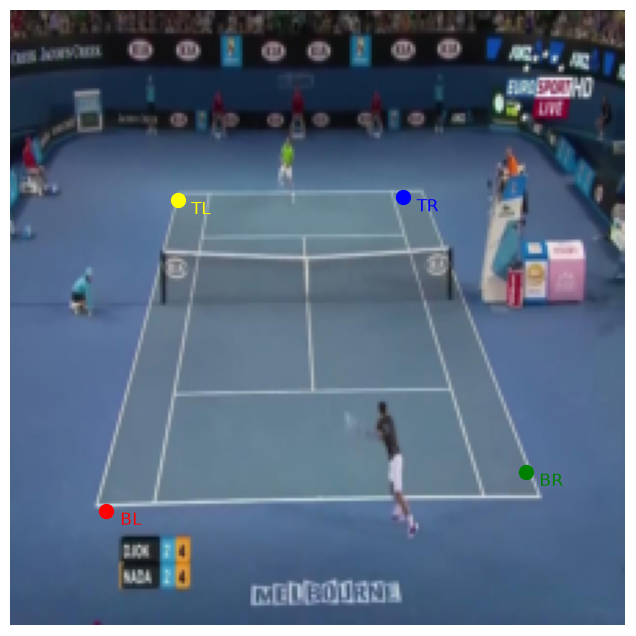

In [192]:
plt.figure(figsize=(8, 8))

plt.imshow(display_image)

colors = ["red", "green", "blue", "yellow"]
names = ["BL", "BR", "TR", "TL"]

for (x, y), color, name in zip(
    prediction_pixels,
    colors,
    names
):
    plt.scatter(x, y, s=100, c=color)
    plt.text(
        x + 5,
        y + 5,
        name,
        fontsize=12,
        color=color
    )

plt.xlim(0, 224)
plt.ylim(224, 0)
plt.axis("off")
plt.show()

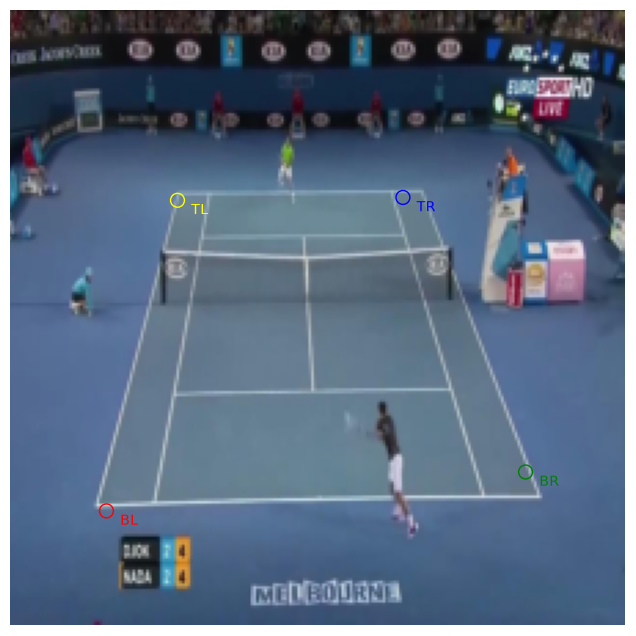

In [193]:
# model.eval()

with torch.no_grad():
    prediction = model(img.unsqueeze(0).to(device))

prediction = prediction.squeeze(0).cpu().numpy()
ground_truth = label.numpy()

# Convert normalized coordinates → 224x224 pixels
prediction *= 224
ground_truth *= 224

plt.figure(figsize=(8, 8))
plt.imshow(display_image)

pred_colors = ["red", "green", "blue", "yellow"]

names = ["BL", "BR", "TR", "TL"]

for i in range(4):

    # Ground truth: X
    plt.scatter(
        ground_truth[i, 0],
        ground_truth[i, 1],
        marker="x",
        s=150,
        linewidths=3,
        color=pred_colors[i]
    )

    # Prediction: circle
    plt.scatter(
        prediction[i, 0],
        prediction[i, 1],
        marker="o",
        s=100,
        facecolors="none",
        edgecolors=pred_colors[i]
    )

    plt.text(
        prediction[i, 0] + 5,
        prediction[i, 1] + 5,
        names[i],
        color=pred_colors[i]
    )

plt.xlim(0, 224)
plt.ylim(224, 0)
plt.axis("off")
plt.show()